# ReducedSymmetryP2P

Compares the default canonical particle-row P2P plan against the explicit `use_reduced_symmetry_p2p` Tensor6 dictionary plan. It reports stored tensors, P2P-plan memory, field agreement, and timed P2P runtime. This notebook is intentionally not executed during installation.

The reduced-symmetry executor is currently CPU-static only; CUDA still uses its existing P2P executors.


to built: 


cmake --preset notebooks
cmake --build --preset notebooks -j
cmake --install build-notebooks

In [ ]:
import cdfmm
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

ORDER = 6
DEPTHS = (2, 3)
GRID_SIDES = (8,10, 15, 20)
WARMUPS = 2
TIMED_EVALUATIONS = 10
SPACING = 1.0
CUBOID_FILL = 1.0  # Cuboids touch: there is no gap.

cube = cdfmm.CuboidSize(CUBOID_FILL * SPACING, CUBOID_FILL * SPACING, CUBOID_FILL * SPACING)
GEOMETRIES = (
    #('point-point', cdfmm.SourceGeometry.POINT_DIPOLE, cdfmm.TargetGeometry.POINT, [], []),
    #('cuboid-point', cdfmm.SourceGeometry.UNIFORM_CUBOID, cdfmm.TargetGeometry.POINT, [cube], []),
    ('cuboid-cuboid', cdfmm.SourceGeometry.UNIFORM_CUBOID, cdfmm.TargetGeometry.VOLUME_AVERAGED_CUBOID, [cube], [cube]),
)

In [2]:
def cartesian_centres(side):
    grid = np.indices((side, side, side), dtype=float).reshape(3, -1).T
    return (grid - (side - 1) / 2.0) * SPACING

def make_fmm(positions, geometry, depth, reduced):
    _, source_geometry, target_geometry, source_sizes, target_sizes = geometry
    options = cdfmm.UniformFmmOptions()
    options.precision = cdfmm.StaticPrecision.FLOAT32
    options.backend = cdfmm.ExecutionBackend.CPU_STATIC
    options.expansion_order = ORDER
    options.tree.max_level = depth
    options.source_geometry, options.target_geometry = source_geometry, target_geometry
    options.source_sizes, options.target_sizes = source_sizes, target_sizes
    options.use_cuboid_p2m = options.use_cuboid_l2p = False
    options.fixed_target_source_indices = list(range(len(positions)))
    options.use_reduced_symmetry_p2p = reduced
    return cdfmm.UniformFmm(positions, positions, options)

def run_case(geometry, side, depth):
    positions = cartesian_centres(side)
    identities = np.arange(len(positions), dtype=np.int32)
    moments = np.random.default_rng(1000 + len(positions)).normal(size=(len(positions), 3))
    canonical = make_fmm(positions, geometry, depth, reduced=False)
    reduced = make_fmm(positions, geometry, depth, reduced=True)
    if canonical.p2p_execution_packing != cdfmm.P2PExecutionPacking.PARTICLE_ROW_SOA:
        raise RuntimeError(f'Canonical comparison resolved {canonical.p2p_execution_packing}; expected PARTICLE_ROW_SOA')
    if reduced.p2p_execution_packing != cdfmm.P2PExecutionPacking.TENSOR_DICTIONARY:
        raise RuntimeError(
            f'Reduced-symmetry P2P was not built (resolved {reduced.p2p_execution_packing}). '
            'Rebuild and reinstall cdfmm, then restart the notebook kernel.'
        )
    for fmm in (canonical, reduced):
        for _ in range(WARMUPS):
            fmm.evaluate(moments, target_source_indices=identities)
    timings = {}
    fields = {}
    for name, fmm in (('canonical', canonical), ('reduced', reduced)):
        samples = []
        for _ in range(TIMED_EVALUATIONS):
            fields[name] = fmm.evaluate(moments, target_source_indices=identities)['H']
            samples.append(1e3 * fmm.last_timings['p2p'])
        timings[name] = samples
    np.testing.assert_allclose(fields['reduced'], fields['canonical'], rtol=5e-5, atol=5e-6)
    difference = np.abs(fields['reduced'] - fields['canonical'])
    canonical_stats, reduced_stats = canonical.static_plan_statistics, reduced.static_plan_statistics
    return dict(geometry=geometry[0], depth=depth, order=ORDER, grid_side=side, particles=len(positions),
                canonical_tensors=canonical_stats['p2p_interactions'],
                reduced_tensors=reduced_stats['p2p_unique_tensors'],
                canonical_tensor_bytes=canonical_stats['p2p_value_bytes'],
                canonical_plan_bytes=canonical_stats['p2p_canonical_total_bytes'],
                reduced_tensor_bytes=reduced_stats['p2p_dictionary_tensor_bytes'],
                reduced_token_bytes=reduced_stats['p2p_dictionary_token_bytes'],
                reduced_plan_bytes=reduced_stats['p2p_dictionary_total_bytes'],
                tensor_reduction=1 - reduced_stats['p2p_unique_tensors'] / canonical_stats['p2p_interactions'],
                plan_memory_reduction=1 - reduced_stats['p2p_dictionary_total_bytes'] / canonical_stats['p2p_canonical_total_bytes'],
                p2p_ms_canonical=float(np.median(timings['canonical'])),
                p2p_ms_reduced=float(np.median(timings['reduced'])),
                p2p_speedup=float(np.median(timings['canonical']) / np.median(timings['reduced'])),
                max_abs_field_difference=float(difference.max()),
                max_relative_field_difference=float(difference.max() / max(np.abs(fields['canonical']).max(), np.finfo(float).tiny)))

In [3]:
rows = [run_case(geometry, side, depth) for geometry in GEOMETRIES for depth in DEPTHS for side in GRID_SIDES]
results = pd.DataFrame(rows)
display(results)

[cdfmm] UniformFmm initialisation
  source_count: 512
  target_count: 512
  expansion_order: 6
  coefficient_count: 49
  expansion_basis: spherical
  precision: float32
  backend.requested: cpu_static
  backend.resolved: cpu_static
  m2l_backend.requested: static
  m2l_backend.resolved: static
  spherical_m2l_backend: static_dense
  static_matrix_backend: portable
  executor.p2m: portable
  executor.m2m: portable
  executor.m2l: portable
  executor.l2l: portable
  executor.l2p: portable
  executor.p2p: portable
  p2p_packing: particle_row_soa
  tree.max_level.requested: 2
  tree.max_level.resolved: 2
  tree.include_empty_nodes: true
  tree.cubic_root_box: true
  tree.root_centre.requested: auto
  tree.root_centre.physical_resolved: [0, 0, 0]
  tree.root_half_width.requested: auto
  tree.root_half_width.physical_resolved: 3.5
  tree.root_side_length.physical_resolved: 7
  tree.root_centre.internal: [0, 0, 0]
  tree.root_half_width.internal: 0.5
  source_geometry: point_dipole
  source_s

,geometry,depth,order,grid_side,particles,canonical_tensors,reduced_tensors,canonical_tensor_bytes,canonical_plan_bytes,reduced_tensor_bytes,reduced_token_bytes,reduced_plan_bytes,tensor_reduction,plan_memory_reduction,p2p_ms_canonical,p2p_ms_reduced,p2p_speedup,max_abs_field_difference,max_relative_field_difference
0,point-point,2,6,8,512,64000,163,1536000,2626052,3912,256000,276684,0.997453,0.894639,0.021809,0.037202,0.586232,1.192093e-07,1.173632e-07
1,point-point,2,6,10,1000,195112,264,4682688,8003596,6336,780448,803556,0.998647,0.899601,0.051155,0.152166,0.336175,1.192093e-07,9.732669e-08
2,point-point,2,6,15,3375,2571353,1390,61712472,105438977,33360,10285412,10335544,0.999459,0.901976,1.403796,2.285003,0.614352,2.384186e-07,1.946297e-07
3,point-point,2,6,20,8000,15625000,3235,375000000,640657004,77640,62500000,62594412,0.999793,0.902297,9.875227,11.081316,0.891160,2.384186e-07,1.892729e-07
4,point-point,3,6,8,512,10648,28,255552,438620,672,42592,219780,0.997370,0.498928,0.010804,0.012639,0.854820,1.192093e-07,1.176113e-07
5,point-point,3,6,10,1000,32768,58,786432,1347492,1392,131072,308980,0.998230,0.770700,0.022471,0.050745,0.442808,1.192093e-07,9.732957e-08
6,point-point,3,6,15,3375,456533,190,10956792,18731357,4560,1826132,2007208,0.999584,0.892842,0.148830,0.380269,0.391380,1.788139e-07,1.459758e-07
7,point-point,3,6,20,8000,2299968,574,55199232,94330692,13776,9199872,9390164,0.999750,0.900455,1.091646,2.318124,0.470918,2.384186e-07,1.893514e-07


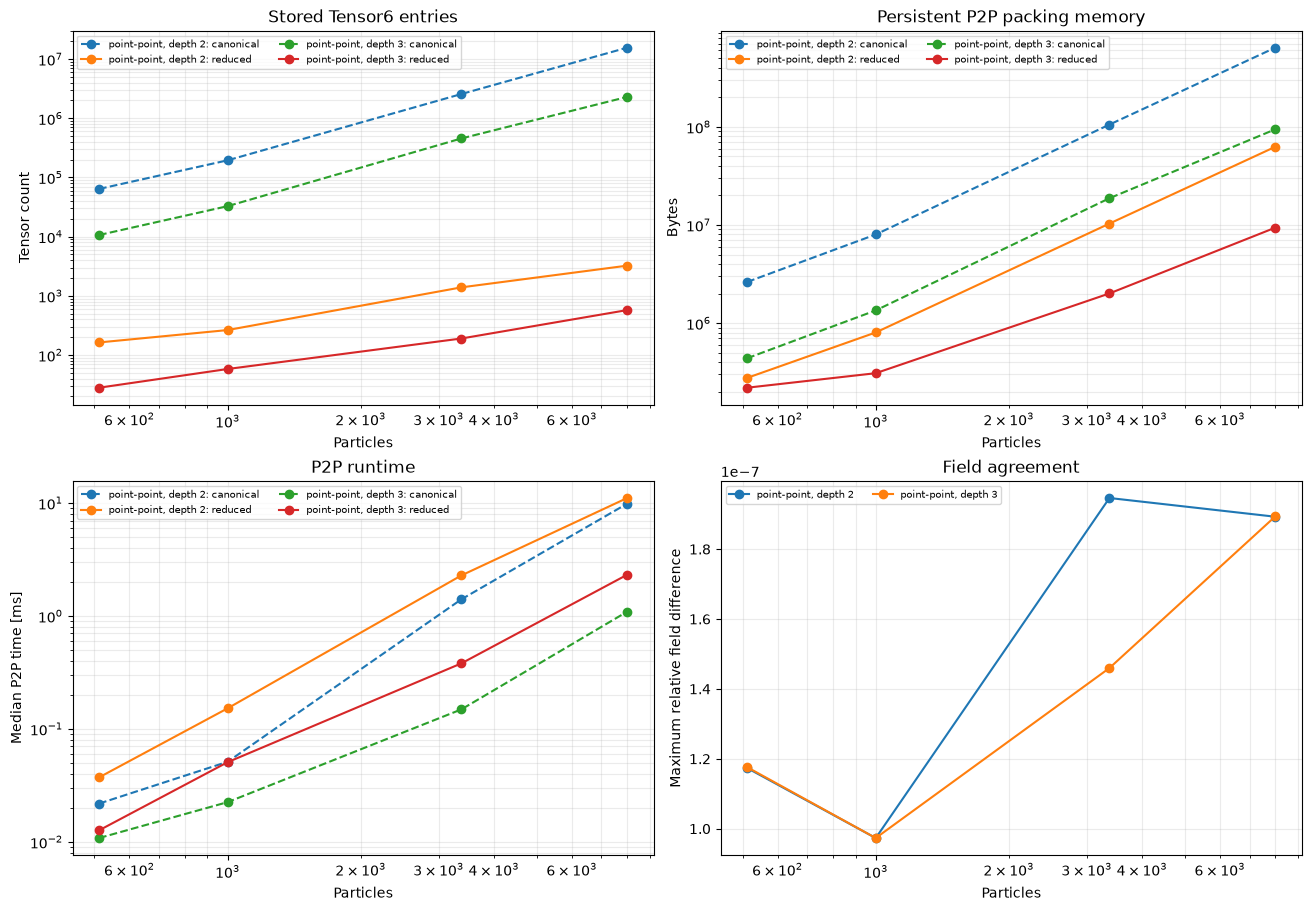

,geometry,depth,particles,tensor_reduction,plan_memory_reduction,p2p_speedup
0,point-point,2,512,0.997453,0.894639,0.586232
1,point-point,2,1000,0.998647,0.899601,0.336175
2,point-point,2,3375,0.999459,0.901976,0.614352
3,point-point,2,8000,0.999793,0.902297,0.891160
4,point-point,3,512,0.997370,0.498928,0.854820
5,point-point,3,1000,0.998230,0.770700,0.442808
6,point-point,3,3375,0.999584,0.892842,0.391380
7,point-point,3,8000,0.999750,0.900455,0.470918


In [4]:
fig, axes = plt.subplots(2, 2, figsize=(13, 9), constrained_layout=True)
for (geometry, depth), group in results.groupby(['geometry', 'depth']):
    label = f'{geometry}, depth {depth}'
    group = group.sort_values('particles')
    axes[0, 0].loglog(group['particles'], group['canonical_tensors'], 'o--', label=f'{label}: canonical')
    axes[0, 0].loglog(group['particles'], group['reduced_tensors'], 'o-', label=f'{label}: reduced')
    axes[0, 1].loglog(group['particles'], group['canonical_plan_bytes'], 'o--', label=f'{label}: canonical')
    axes[0, 1].loglog(group['particles'], group['reduced_plan_bytes'], 'o-', label=f'{label}: reduced')
    axes[1, 0].loglog(group['particles'], group['p2p_ms_canonical'], 'o--', label=f'{label}: canonical')
    axes[1, 0].loglog(group['particles'], group['p2p_ms_reduced'], 'o-', label=f'{label}: reduced')
    axes[1, 1].semilogx(group['particles'], group['max_relative_field_difference'], 'o-', label=label)

axes[0, 0].set(title='Stored Tensor6 entries', xlabel='Particles', ylabel='Tensor count')
axes[0, 1].set(title='Persistent P2P packing memory', xlabel='Particles', ylabel='Bytes')
axes[1, 0].set(title='P2P runtime', xlabel='Particles', ylabel='Median P2P time [ms]')
axes[1, 1].set(title='Field agreement', xlabel='Particles', ylabel='Maximum relative field difference')
for axis in axes.flat:
    axis.grid(True, which='both', alpha=0.25)
    axis.legend(fontsize=7, ncol=2)
plt.show()

display(results[['geometry', 'depth', 'particles', 'tensor_reduction', 'plan_memory_reduction', 'p2p_speedup']])